# Consistency losses in practice

What the objectives in `consistency_losses.md` actually look like on maze rollouts: their magnitude, their
spread across trajectories, how they scale with trajectory length, and how big a gradient they put on the
shared weights relative to the data loss.

Nothing here changes the model. `MazeTransformer` already emits value logits at every slot and
`make_forward` already reads them at every state slot, so the reward head at every prefix h_0..h_n is
already there. All the new code is in `maze_consistency/consistency.py`.

**One block = one env step.** The value head is only read at state slots, so interval endpoints sit between a
state and the action that follows it (note section 7). `u_t`/`v_t` are the *full* flat next-token log-softmax
over the action slot plus the dynamics slot -- not the action-only slice, because renormalizing per slot type
adds a log-partition term to `delta` that does not telescope.

In [4]:
import numpy as np, jax, jax.numpy as jnp, matplotlib.pyplot as plt

from maze_consistency.dataset import load
from maze_consistency.tokens import Tokenizer
from maze_consistency.model import MazeTransformer, next_token_loss
from maze_consistency.train import train, LossConfig, N_HELDOUT
import maze_consistency.consistency as C

STEPS    = 400    # ~250 ms/step on CPU
BATCH    = 32
N_SAMPLE = 64     # held-out rollouts to measure the losses on
SEED     = 0

maze, d = load()
tok = Tokenizer(maze)
print(maze, "| slots per sequence:", tok.L)

Maze(canon12: 12x12, max dist=20, T=200, K=12, gamma=0.95) | slots per sequence: 402


## 1. A short training run

Plain teacher forcing plus the MC value loss. The value head has to be trained or `b_t = log q_t(R)` is
noise and every consistency number below is meaningless. `LossConfig(mc=True)` is the note's `L_data`:
next-token likelihood in both modes (the batch is half NOR, half R) plus reward supervision at every prefix.

No consistency term is in the loss yet -- section 6 adds one. Everything up to there measures what these
objectives *would* see on a model trained without them.

In [5]:
params, cfg = train(name="consistency_demo", steps=STEPS, batch=BATCH, seed=SEED,
                    loss=LossConfig(mc=True), log_every=max(STEPS // 8, 1))
model = MazeTransformer(cfg)
terms_fn = C.make_terms_fn(model, tok)

[consistency_demo] Maze(canon12: 12x12, max dist=20, T=200, K=12, gamma=0.95) params=139,361 train=99,000 held-out=1000 loss=LossConfig(mc=True, td=False, a=False, w_mc=1.0, w_td=1.0, a_updates=4, a_batch=16, lr_a=0.0001, a_warmup=0.25)
  step 50: mc 0.5632 tf 3.2624 (276 ms/step)
  step 100: mc 0.3979 tf 2.3437 (251 ms/step)
  step 150: mc 0.4968 tf 1.8626 (246 ms/step)
  step 200: mc 0.4184 tf 1.5277 (244 ms/step)
  step 250: mc 0.3979 tf 1.3277 (243 ms/step)
  step 300: mc 0.4128 tf 1.1854 (242 ms/step)
  step 350: mc 0.4294 tf 1.0821 (240 ms/step)
  step 400: mc 0.4035 tf 1.0068 (239 ms/step)


## 2. Magnitude and spread

Held-out rollouts, one batch. Every loss is per trajectory, so these are distributions over trajectories, not
a single scalar. The column that matters is `std/mean`: a loss whose value swings by a factor of several
across trajectories in a batch will make the gradient noisy no matter what `lambda_cons` is.

In [6]:
rng = np.random.default_rng(SEED)
n_train = len(d["length"]) - N_HELDOUT
held = np.arange(n_train, n_train + N_HELDOUT)
idx = rng.choice(held, N_SAMPLE, replace=False)

# A natural batch is mostly n = T (the random walk truncates without reaching the goal ~70% of the time),
# which hides every length effect. `strat` is a second sample spread evenly over length for the scaling plot.
hl = d["length"][held]
uniq = np.unique(hl)                                    # spread over distinct lengths, not over rollouts
pick = uniq[np.linspace(0, len(uniq) - 1, min(N_SAMPLE, len(uniq))).astype(int)]
strat = np.array([rng.choice(held[hl == L]) for L in pick])

batch = C.rollout_batch(tok, maze, d, idx)
t, r, losses, diag = C.evaluate(params, terms_fn, batch)
n = np.asarray(batch["lengths"])
print(f"{N_SAMPLE} held-out rollouts | n: min {n.min()} median {int(np.median(n))} max {n.max()}"
      f" | reached goal: {(n < maze.T).sum()}/{N_SAMPLE}")

rows = []
for k, v in losses.items():
    v = np.asarray(v)
    rows.append((k, v.mean(), v.std(), v.std() / v.mean(), v.min(), v.max(), v.max() / v.min()))
print(f"\n{'loss':<12}{'mean':>10}{'std':>10}{'std/mean':>10}{'min':>10}{'max':>10}{'max/min':>10}")
for k, m, s, cv, lo, hi, ratio in rows:
    print(f"{k:<12}{m:10.4f}{s:10.4f}{cv:10.2f}{lo:10.4f}{hi:10.4f}{ratio:10.1f}")

64 held-out rollouts | n: min 1 median 200 max 200 | reached goal: 18/64

loss              mean       std  std/mean       min       max   max/min
local           0.0244    0.0473      1.94    0.0002    0.2769    1370.8
all             0.2838    0.5452      1.92    0.0063    3.0941     490.5
all_scaled      0.0202    0.0530      2.62    0.0001    0.3583    3824.0
mixed           0.0223    0.0464      2.08    0.0002    0.2351    1403.8
poly_len        0.4034    0.7706      1.91    0.0083    4.3480     525.7
multiscale      0.0215    0.0484      2.25    0.0001    0.2655    1958.4


## 3. How each loss scales with trajectory length

The absolute loss is not a clean read on length: short rollouts here are the ones that reached the goal
quickly, so their residuals differ in kind, not just in count. What isolates the interval-count effect is the
**ratio `L_all / L_local`** against the note's `s(n) = (n+2)/3`, which is exactly what that ratio would be if
the local residuals were iid and zero-mean. Ratio/s(n) near 1 means `s(n)` is the right normalizer; well
below 1 means residuals anti-correlate over long spans and `s(n)` over-corrects.

The concentration panel is the batch-composition warning from note section 6: pooling pairs across a batch
instead of averaging per trajectory would give long examples quadratically more weight.

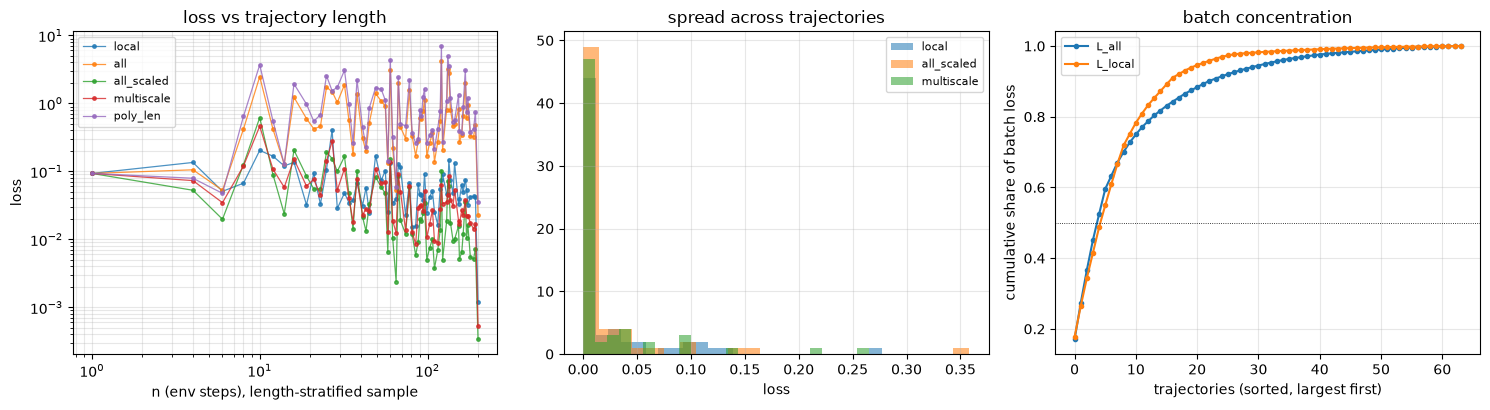

half of the batch's L_all comes from 5/64 trajectories (6/64 for L_local)

L_all / L_local against the iid prediction s(n) = (n+2)/3:
      n     ratio      s(n)  ratio/s(n)
      1      1.00      1.00        1.00
     21      4.51      7.67        0.59
     41      9.80     14.33        0.68
     65      1.36     22.33        0.06
     92     13.27     31.33        0.42
    121     56.49     41.00        1.38
    155      6.98     52.33        0.13
    200     18.91     67.33        0.28


In [7]:
batch_s = C.rollout_batch(tok, maze, d, strat)
_, _, losses_s, _ = C.evaluate(params, terms_fn, batch_s)
ns = np.asarray(batch_s["lengths"])

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for k in ["local", "all", "all_scaled", "multiscale", "poly_len"]:
    o = np.argsort(ns)
    ax[0].plot(ns[o], np.asarray(losses_s[k])[o], ".-", ms=5, lw=.9, alpha=.8, label=k)
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].set_xlabel("n (env steps), length-stratified sample")
ax[0].set_ylabel("loss"); ax[0].set_title("loss vs trajectory length"); ax[0].legend(fontsize=8)
ax[0].grid(alpha=.3, which="both")

for k in ["local", "all_scaled", "multiscale"]:
    ax[1].hist(np.asarray(losses[k]), bins=24, alpha=.55, label=k)
ax[1].set_xlabel("loss"); ax[1].set_title("spread across trajectories"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

# share of the batch's total all-interval loss held by each trajectory, sorted
sh = np.sort(np.asarray(losses["all"]))[::-1]; sh = sh / sh.sum()
ax[2].plot(np.cumsum(sh), ".-", label="L_all")
sl = np.sort(np.asarray(losses["local"]))[::-1]; sl = sl / sl.sum()
ax[2].plot(np.cumsum(sl), ".-", label="L_local")
ax[2].axhline(.5, color="k", lw=.6, ls=":"); ax[2].set_xlabel("trajectories (sorted, largest first)")
ax[2].set_ylabel("cumulative share of batch loss"); ax[2].set_title("batch concentration")
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

half = np.searchsorted(np.cumsum(sh), .5) + 1
print(f"half of the batch's L_all comes from {half}/{N_SAMPLE} trajectories "
      f"({np.searchsorted(np.cumsum(sl), .5) + 1}/{N_SAMPLE} for L_local)")
ratio = np.asarray(losses_s["all"]) / np.maximum(np.asarray(losses_s["local"]), 1e-12)
pred = (ns + 2) / 3.0
o = np.argsort(ns)
print()
print("L_all / L_local against the iid prediction s(n) = (n+2)/3:")
print(f"  {'n':>5}{'ratio':>10}{'s(n)':>10}{'ratio/s(n)':>12}")
for i in o[np.linspace(0, len(o) - 1, 8).astype(int)]:
    print(f"  {ns[i]:5d}{ratio[i]:10.2f}{pred[i]:10.2f}{ratio[i]/pred[i]:12.2f}")

## 4. The residuals themselves

`delta_t` split into its three sources. The maze has deterministic transitions, so `v_dyn - u_dyn` should
cancel on valid paths (note section 7) -- how close it is to zero says how well the model has learned that
the dynamics do not depend on R. What is left is the policy term `v_pi - u_pi` against the value-head step
`b_{t-1} - b_t`.

Interval RMS by length distinguishes the two regimes the note cares about: iid residuals diffuse
(`rms ~ sqrt(l)`), same-sign residuals drift (`rms ~ l`). `L_all` is only worth its extra weighting if the
curve is above the `sqrt(l)` reference.

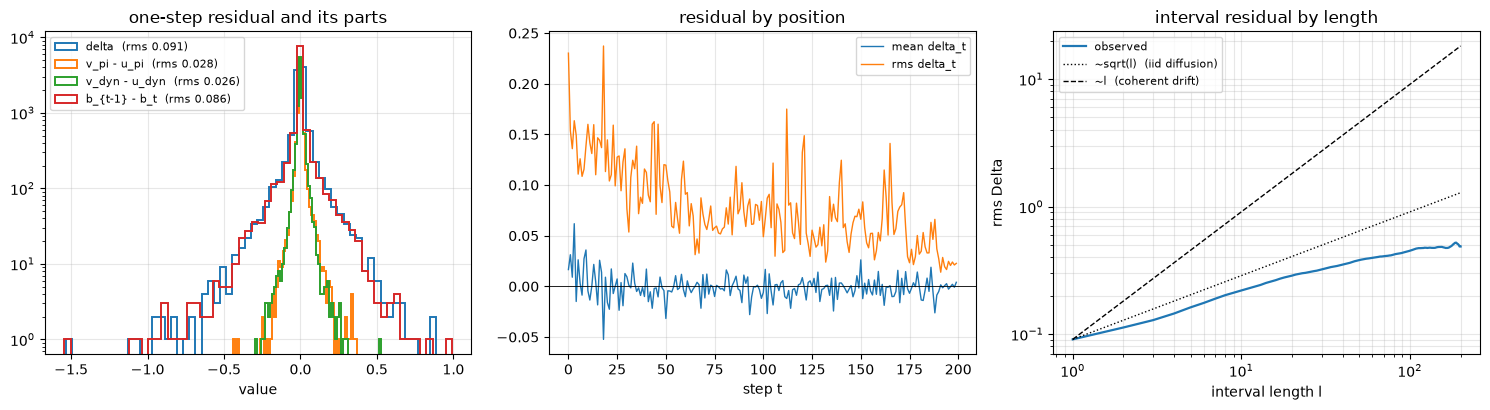

rms Delta ~ l^0.29   (0.5 = pure diffusion, 1.0 = coherent drift)
   residuals cancel over long spans: the extra long-range weight in L_all is buying little here, which is the case the note's retained local term exists for
dynamics term rms 0.0264 vs policy term rms 0.0281  <- deterministic transitions should push the first toward 0


In [8]:
edge = np.asarray(r["edge"]); delta = np.asarray(r["delta"])
dpi  = np.asarray(t["v_pi"]  - t["u_pi"])
ddyn = np.asarray(t["v_dyn"] - t["u_dyn"])
db   = np.asarray(t["b"][:, :-1] - t["b"][:, 1:])
flat = lambda z: z[edge]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for z, lab in [(delta, "delta"), (dpi, "v_pi - u_pi"), (ddyn, "v_dyn - u_dyn"), (db, "b_{t-1} - b_t")]:
    ax[0].hist(flat(z), bins=60, histtype="step", lw=1.4, label=f"{lab}  (rms {np.sqrt((flat(z)**2).mean()):.3f})")
ax[0].set_yscale("log"); ax[0].set_xlabel("value"); ax[0].set_title("one-step residual and its parts")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

tt = np.arange(delta.shape[1]); cnt = edge.sum(0)
keep = cnt >= 5
mean_t = np.where(cnt > 0, (delta * edge).sum(0) / np.maximum(cnt, 1), np.nan)
rms_t  = np.sqrt(np.where(cnt > 0, (delta**2 * edge).sum(0) / np.maximum(cnt, 1), np.nan))
ax[1].plot(tt[keep], mean_t[keep], lw=1, label="mean delta_t")
ax[1].plot(tt[keep], rms_t[keep], lw=1, label="rms delta_t")
ax[1].axhline(0, color="k", lw=.6); ax[1].set_xlabel("step t"); ax[1].set_title("residual by position")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

ell, rms, _ = C.interval_stats_by_length(np.asarray(r["c"]), n)
ax[2].loglog(ell, rms, lw=1.6, label="observed")
ax[2].loglog(ell, rms[0] * np.sqrt(ell), "k:", lw=1, label="~sqrt(l)  (iid diffusion)")
ax[2].loglog(ell, rms[0] * ell, "k--", lw=1, label="~l  (coherent drift)")
ax[2].set_xlabel("interval length l"); ax[2].set_ylabel("rms Delta"); ax[2].set_title("interval residual by length")
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

slope = np.polyfit(np.log(ell[1:]), np.log(rms[1:]), 1)[0]
verdict = ("residuals cancel over long spans: the extra long-range weight in L_all is buying little here,"
           " which is the case the note's retained local term exists for") if slope < 0.55 else (
           "residuals accumulate coherently: this is the regime L_all is designed to catch")
print(f"rms Delta ~ l^{slope:.2f}   (0.5 = pure diffusion, 1.0 = coherent drift)")
print("  ", verdict)
print(f"dynamics term rms {np.sqrt((flat(ddyn)**2).mean()):.4f} vs policy term rms {np.sqrt((flat(dpi)**2).mean()):.4f}"
      "  <- deterministic transitions should push the first toward 0")

## 5. What each loss weights, and how hard it pulls

`L_all` is `delta^T A delta` with `A[s,t] = min(s,t)(n+1-max(s,t))`, so as a weighting of the individual
steps it is a parabola: the middle of the trajectory gets O(n^2/4) weight and the two ends O(n). That
down-weights exactly the endpoints you most want pinned -- `q_0` (the prior over R) and `q_n` (the terminal
anchor, where the recorded trajectory determines R).

The right panel is the practical number for picking `lambda_cons`: the gradient norm each objective puts on
the shared weights, against the data loss. Equal loss values do not mean equal optimization influence.

n=200: L_all weights the middle step 50x the first/last step


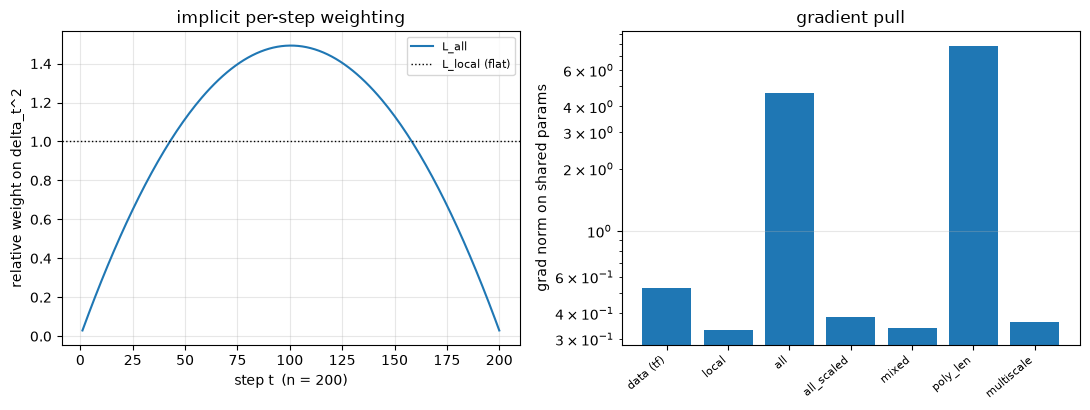


data loss grad norm 0.5296
  local           0.3306   lambda for a 10% pull:   0.1602
  all             4.6312   lambda for a 10% pull:   0.0114
  all_scaled      0.3852   lambda for a 10% pull:   0.1375
  mixed           0.3394   lambda for a 10% pull:   0.1560
  poly_len        7.8813   lambda for a 10% pull:   0.0067
  multiscale      0.3627   lambda for a 10% pull:   0.1460


In [9]:
nn_ = int(np.median(n))
prof = C.weight_profile(nn_).astype(float)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(np.arange(1, nn_ + 1), prof / prof.mean(), label="L_all")
ax[0].axhline(1.0, color="k", lw=1, ls=":", label="L_local (flat)")
ax[0].set_xlabel(f"step t  (n = {nn_})"); ax[0].set_ylabel("relative weight on delta_t^2")
ax[0].set_title("implicit per-step weighting"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
print(f"n={nn_}: L_all weights the middle step {prof.max()/prof[0]:.0f}x the first/last step")

jb = {k: jnp.asarray(batch[k]) for k in ("x_nor", "x_R", "targets", "R_bin")}
gnorm = lambda g: float(jnp.sqrt(sum((x**2).sum() for x in jax.tree_util.tree_leaves(g))))

def cons_loss(p, key):
    tt_ = terms_fn(p, jb["x_nor"], jb["x_R"], jb["targets"], jb["R_bin"])
    return C.ALL[key](C.residuals(tt_["u"], tt_["v"], tt_["b"], batch["lengths"])).mean()

def data_loss(p):
    out = model.apply({"params": p}, jb["x_nor"], jnp.asarray(tok.types))
    return next_token_loss(out["next"], jb["targets"], jnp.asarray(batch["x_nor"][:, :-1, 0] != tok.PAD))

keys = list(C.ALL)
g_data = gnorm(jax.grad(data_loss)(params))
g_cons = {k: gnorm(jax.grad(cons_loss)(params, k)) for k in keys}
ax[1].bar(range(len(keys) + 1), [g_data] + [g_cons[k] for k in keys])
ax[1].set_xticks(range(len(keys) + 1)); ax[1].set_xticklabels(["data (tf)"] + keys, rotation=40, ha="right", fontsize=8)
ax[1].set_yscale("log"); ax[1].set_ylabel("grad norm on shared params"); ax[1].set_title("gradient pull")
ax[1].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

print(f"\ndata loss grad norm {g_data:.4f}")
for k in keys:
    print(f"  {k:<12} {g_cons[k]:9.4f}   lambda for a 10% pull: {0.1 * g_data / g_cons[k]:8.4f}")

## 6. Training with a consistency term

A self-contained loop, deliberately not folded into `train.py`: one update on the data loss plus
`lambda_cons` times the chosen consistency loss, both orderings on the *same* rollouts (which is why this
needs its own batch -- `train.make_batch` puts NOR and R rows on *different* rollouts).

The tracked diagnostics are the collapse check. Every loss here has the same degenerate global minimum:
`v_t == u_t` and `b_t` constant in `t` -- i.e. ignore R entirely -- makes every residual exactly zero. If
`cond_gap` (mean `|v_t - u_t|`) or `info_gain` (`log q_n(R) - log q_0(R)`) falls toward zero while the
consistency loss falls, the model is buying agreement by throwing away the reward channel.

  step    1: cond_gap 0.0626  cons 0.0409  data 2.3024  info_gain 0.5748
  step   25: cond_gap 0.0113  cons 0.0027  data 2.4957  info_gain 0.3208
  step   50: cond_gap 0.0392  cons 0.0035  data 2.4866  info_gain 0.3562
  step   75: cond_gap 0.0095  cons 0.0005  data 1.9125  info_gain 0.2008
  step  100: cond_gap 0.0141  cons 0.0037  data 2.1361  info_gain 0.3849
  step  125: cond_gap 0.0111  cons 0.0013  data 2.0801  info_gain 0.3845
  step  150: cond_gap 0.0298  cons 0.0061  data 2.0962  info_gain 0.2959


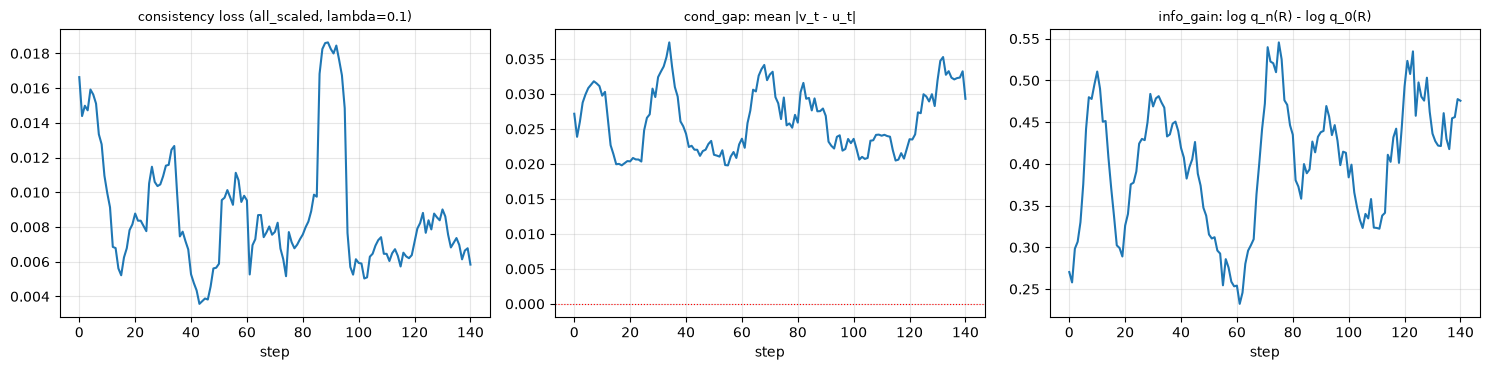

collapse check -- both of these should hold up, not decay toward 0:
  cond_gap  0.0272 -> 0.0293
  info_gain 0.2703 -> 0.4756


In [10]:
import optax
from dataclasses import replace

LOSS_KEY   = "all_scaled"   # any key in C.ALL
LAMBDA     = 0.1
W_REWARD   = 1.0            # keep the reward head supervised, or consistency alone will collapse it
CONS_STEPS = 150
CONS_BATCH = 16

def total_loss(p, jb_, lengths_, tgt_mask):
    # one terms_fn call = the two passes; the data loss reuses their gathered log probs
    tt_ = terms_fn(p, jb_["x_nor"], jb_["x_R"], jb_["targets"], jb_["R_bin"])
    rr  = C.residuals(tt_["u"], tt_["v"], tt_["b"], lengths_)
    tf_ = C.data_nll(tt_["lp_nor"], tgt_mask) + C.data_nll(tt_["lp_R"], tgt_mask)   # both orderings
    nd  = rr["node"].astype(jnp.float32)
    rew = -(tt_["b"] * nd).sum() / nd.sum()          # reward supervision at every prefix (the note's gamma term)
    data = tf_ + W_REWARD * rew
    cons = C.ALL[LOSS_KEY](rr).mean()
    dg = C.diagnostics(rr, tt_["u"], tt_["v"], tt_["b"])
    return data + LAMBDA * cons, dict(data=data, cons=cons,
                                      cond_gap=dg["cond_gap"].mean(), info_gain=dg["info_gain"].mean())

opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(1e-3))
opt_state = opt.init(params)
p = params

@jax.jit
def step(p, opt_state, jb_, lengths_, tgt_mask):
    (_, parts), g = jax.value_and_grad(total_loss, has_aux=True)(p, jb_, lengths_, tgt_mask)
    upd, opt_state = opt.update(g, opt_state, p)
    return optax.apply_updates(p, upd), opt_state, parts

hist = []
for i in range(1, CONS_STEPS + 1):
    bi = C.rollout_batch(tok, maze, d, rng.integers(0, n_train, CONS_BATCH))
    jbi = {k: jnp.asarray(bi[k]) for k in ("x_nor", "x_R", "targets", "R_bin")}
    mask = jnp.asarray(bi["x_nor"][:, :-1, 0] != tok.PAD)
    p, opt_state, parts = step(p, opt_state, jbi, jnp.asarray(bi["lengths"]), mask)
    hist.append({k: float(v) for k, v in parts.items()})
    if i % 25 == 0 or i == 1:
        print(f"  step {i:4d}: " + "  ".join(f"{k} {v:.4f}" for k, v in hist[-1].items()))

h = {k: np.array([r[k] for r in hist]) for k in hist[0]}
sm = lambda z, w=10: np.convolve(z, np.ones(w) / w, "valid")
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for a, k, ttl in zip(ax, ["cons", "cond_gap", "info_gain"],
                     [f"consistency loss ({LOSS_KEY}, lambda={LAMBDA})",
                      "cond_gap: mean |v_t - u_t|", "info_gain: log q_n(R) - log q_0(R)"]):
    a.plot(sm(h[k])); a.set_title(ttl, fontsize=9); a.set_xlabel("step"); a.grid(alpha=.3)
ax[1].axhline(0, color="r", lw=.8, ls=":")
plt.tight_layout(); plt.show()
print("collapse check -- both of these should hold up, not decay toward 0:")
print(f"  cond_gap  {h['cond_gap'][:10].mean():.4f} -> {h['cond_gap'][-10:].mean():.4f}")
print(f"  info_gain {h['info_gain'][:10].mean():.4f} -> {h['info_gain'][-10:].mean():.4f}")

## Hacking this

- **Swap the loss**: `LOSS_KEY` above, anything in `C.ALL` (`local`, `all`, `all_scaled`, `mixed`,
  `poly_len`, `multiscale`). Add your own by writing a function of the `residuals()` dict and putting it in
  `C.ALL`.
- **Custom length weighting**: `C.poly_loss(r, coefs)` takes any polynomial in interval length in O(dn) --
  `(1.0,)` is uniform, `(0.0, 1.0)` weights by length, `(1.0, 0.5)` blends. The note's `1/l` equalizing
  weight is not polynomial; that one needs `C.multiscale_loss`.
- **Check a change**: `C.all_pairs_bruteforce(c_row, n, coefs)` enumerates every interval explicitly. The
  fast forms are validated against it (values and gradients) in `tests/test_consistency.py`.
- **Include the empty prefix**: the nodes here are h_0..h_n with h_0 = the start cell. Anchoring one node
  earlier (the slot after MODE, so `b_{-1}` is the prior over R before the start cell is seen) adds the
  `p(s_0 | R)` block. Read `out["value"][:, 0]` and prepend.
- **Longer sequences**: `residuals()` casts to float32 and the cumsum is exact enough at n=200; at much
  larger n compare against `jax_enable_x64`.